# K-Nearest Neighbors

En este script de Python veremos como implementar en código todo lo que vimos ya conceptualmente. Python tiene muchas funciones que nos facilitan la vida, y por eso es importante saber qué es lo que está haciendo la computadora cuando hacemos código, y no sólo escribir código a lo tonto.

### Paso 1: Importamos las principales bibliotecas que vamos a utilizar en la sesión.
Abrá otras que importareamos después según vayamos requiriendo las funciones

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Paso 2: descargo e importo la base de datos

In [56]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/d546eaee765268bf2f487608c537c05e22e4b221/iris.csv'

In [57]:
iris = pd.read_csv(url)
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Imaginémonos que nuestro KNN va a clasificar con base en dos atributos nada más. ¿Qué vemos en la gráfica? Los azules todo bien pero, ¿es clara la "diferencia" entre naranjas y verdes? ¿Cómo lo podríamos solucionar?


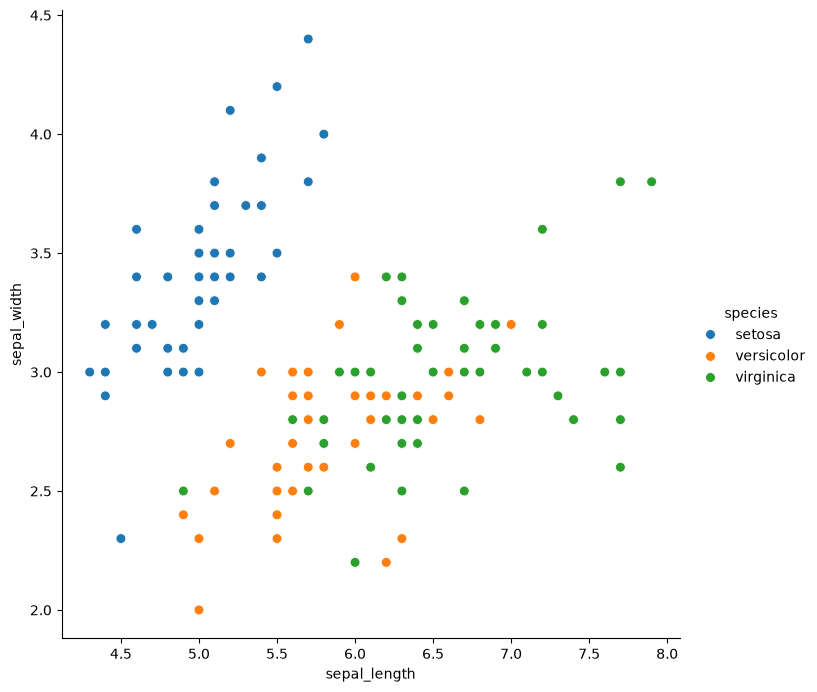

In [58]:
sns.pairplot(x_vars='sepal_length', y_vars='sepal_width', data=iris, plot_kws={'s': 50}, height=7, hue='species')

### Paso 3: Separo mi base en atributos (variables independientes, si quieren verlo así) y etiquetas (variable dependiente)

In [59]:
# Set de características
x = iris.iloc[:, :4].values # 0, 1, 2, 3
x

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [60]:
# Columna de respuestas
y = iris.iloc[:, 4].values
y

<StringArray>
[   'setosa',    'setosa',    'setosa',    'setosa',    'setosa',    'setosa',
    'setosa',    'setosa',    'setosa',    'setosa',
 ...
 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica',
 'virginica', 'virginica', 'virginica', 'virginica']
Length: 150, dtype: str

#¿Knearest ?

![knearest](https://miro.medium.com/max/1022/1*AuXDgGrr0wbCoF6KDXXSZQ.jpeg)


El algoritmo k-nearest neighbors (KNN) es un algoritmo de aprendizaje automático simple y supervisado que puede utilizarse para resolver tanto problemas de clasificación como de regresión. Es fácil de implementar y entender, pero tiene el gran inconveniente de volverse significativamente lento a medida que crece el tamaño de los datos en uso.
KNN funciona encontrando las distancias entre una consulta y todos los ejemplos de los datos, seleccionando el número especificado de ejemplos (K) más cercanos a la consulta, y luego vota por la etiqueta más frecuente (en el caso de la clasificación) o promedia las etiquetas (en el caso de la regresión).
En el caso de la clasificación y la regresión, la elección de la K correcta para nuestros datos se realiza probando varias K y eligiendo la que mejor funciona.


En la clasificación k-NN, el resultado es la pertenencia a una clase. Un objeto se clasifica mediante un voto plural de sus vecinos, asignando el objeto a la clase más común entre sus k vecinos más cercanos (k es un número entero positivo, normalmente pequeño). Si k = 1, el objeto se asigna simplemente a la clase de ese único vecino más cercano.

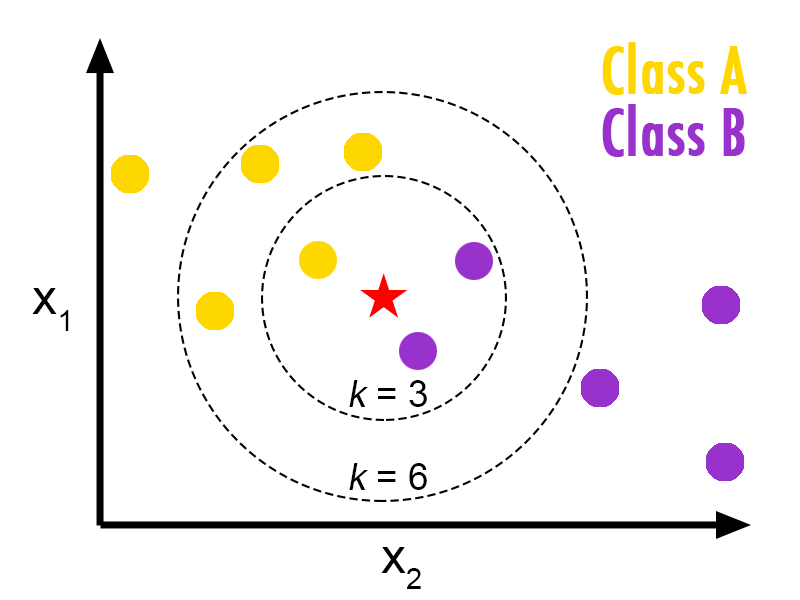

![tomato](https://jiayiwangjw.github.io/img/KNN/tomato.png)

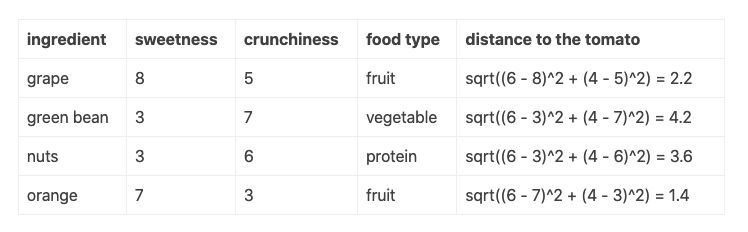

### Paso 4: Vamos a dividir nuestra base en una base de entrenamiento y otra de prueba. Dejemos 80% para que el KNN memorice, y 20% para ver qué tan bien "aprendió" a clasificar

In [61]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [62]:
# Conjunto de entrenamiento
len(x_train)

120

In [63]:
# Conjunto de pruebas
len(x_test)

30

En teoría, una buena K para empezar a explorar es la raíz cuadrada del número de observaciones de mi base de entrenamiento. En este caso es la raíz de 120, es decir, 11 aproximadamente.

In [64]:
import math
math.sqrt(len(x_train))

10.954451150103322

![good_k](https://jiayiwangjw.github.io/img/KNN/how%20much%20is%20K.png)

### Paso 5: Normalizo mis datos para que tengan una escala común

Primero importo la función que me permite normalizar facilmente, y luego le digo que calcule media y desviación que va a usar luego para normalizar (en la parte del fit).

In [65]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(x_train) # Construimos las equivalencias
# 7.3 -> 1, 5.0 -> 0, 6.1 -> 0.5

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](4,)","[7.9,4.4,6.9,2.5]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](4,)","[4.4,2. ,1. ,0.1]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](4,)","[3.5,2.4,5.9,2.4]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](4,)","[-1.26,-0.83,-0.17,-0.04]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,120
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](4,)","[0.29,0.42,0.17,0.42]"


Ahora sí, re-escalo mis variables

In [66]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)
x_test

array([[ 0.8       ,  0.66666667,  0.86440678,  1.        ],
       [ 0.6       ,  0.33333333,  0.61016949,  0.58333333],
       [ 0.4       ,  0.29166667,  0.49152542,  0.45833333],
       [ 0.2       ,  0.70833333,  0.08474576,  0.125     ],
       [ 0.6       ,  0.41666667,  0.81355932,  0.875     ],
       [ 0.34285714,  0.29166667,  0.54237288,  0.5       ],
       [ 0.54285714,  0.20833333,  0.66101695,  0.58333333],
       [ 0.31428571,  0.91666667,  0.06779661,  0.04166667],
       [ 0.68571429,  0.41666667,  0.76271186,  0.83333333],
       [ 0.94285714,  0.33333333,  0.96610169,  0.79166667],
       [ 0.22857143,  0.29166667,  0.49152542,  0.54166667],
       [ 0.2       ,  0.58333333,  0.08474576,  0.04166667],
       [ 0.48571429,  0.375     ,  0.62711864,  0.54166667],
       [ 0.54285714,  0.125     ,  0.57627119,  0.5       ],
       [-0.02857143,  0.41666667,  0.01694915,  0.        ],
       [ 0.34285714,  0.20833333,  0.49152542,  0.41666667],
       [ 0.71428571,  0.

In [67]:
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

### Paso 6: Importo mi clasificador y le digo que memorice los datos de entrenamiento

In [68]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=11)
classifier.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### Paso 7: Hago la predicción con mis atributos del set de prueba

In [69]:
y_pred = classifier.predict(x_test)
y_pred

array(['virginica', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'versicolor', 'virginica', 'setosa', 'virginica', 'virginica',
       'versicolor', 'setosa', 'versicolor', 'versicolor', 'setosa',
       'versicolor', 'virginica', 'virginica', 'setosa', 'setosa',
       'virginica', 'setosa', 'versicolor', 'setosa', 'virginica',
       'virginica', 'setosa', 'versicolor', 'virginica', 'versicolor'],
      dtype=object)

### Paso 8: revisamos qué tan bien lo hicimos

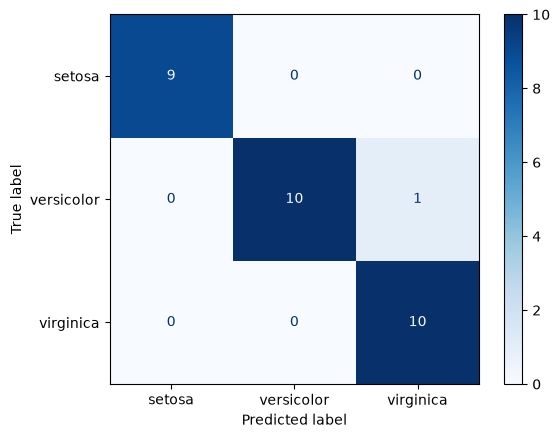

In [70]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ['setosa', 'versicolor', 'virginica']
normalize = None
ConfusionMatrixDisplay.from_estimator(
        classifier,
        x_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )

In [71]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       1.00      0.91      0.95        11
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



**EXTRA: podemos ver con nuestro set de prueba el número de errores promedio que tendríamos con distintas K's

In [72]:
error = []

for i in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(x_train, y_train)
    pred_i = knn.predict(x_test)
    error.append(np.mean(pred_i != y_test))

error

[np.float64(0.03333333333333333),
 np.float64(0.0),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.06666666666666667),
 np.float64(0.03333333333333333),
 np.float64(0.06666666666666667),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.03333333333333333),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.03333333333333333),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.03333333333333333),
 np.float64(0.03333333333333333),
 np.fl

(0.0, 0.2)

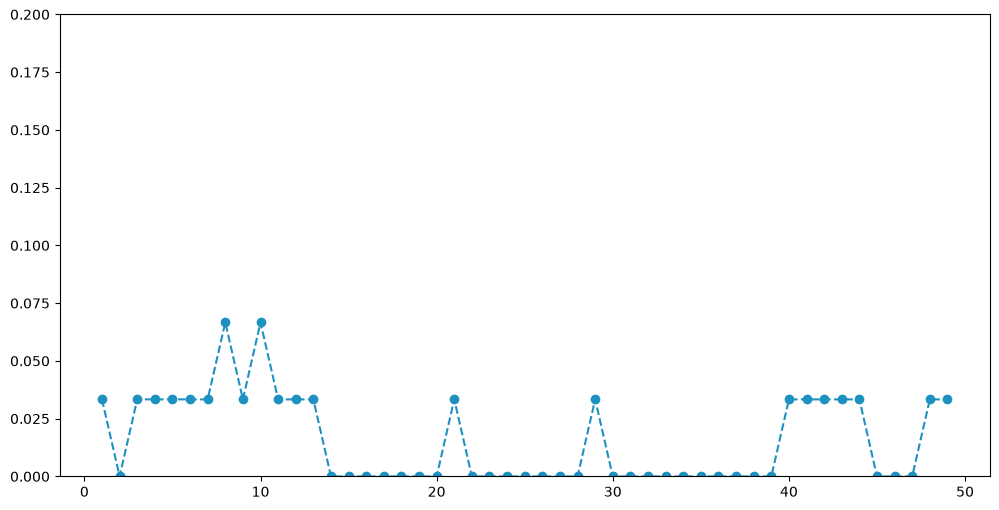

In [73]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 50), error, color = '#1d91c0', linestyle = 'dashed', marker = 'o')
plt.ylim(0, 0.2)

# Challenge: Cancer data

## Objetivo:
Detectar los tumores malignos y beningnos mediante el dataset que recaba múltiples características

1. Aplicar el algoritmo de KNN a ([data.csv](https://drive.google.com/file/d/18f1srPV-Bwp_JH_t4_eujW1MgY1H3rZv/view?usp=drive_link))
2. Evaluar el rendimiento del modelo

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def evaluar_knn_con_validacion(X, y, nombre_dataset, etiquetas=None, k_values=range(1, 26, 2)):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    cv_folds = max(2, min(5, y_train.value_counts().min()))

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier()),
    ])

    busqueda = GridSearchCV(
        estimator=pipeline,
        param_grid={"knn__n_neighbors": list(k_values)},
        cv=cv_folds,
        scoring="accuracy",
        n_jobs=-1,
    )
    busqueda.fit(X_train, y_train)

    mejor_modelo = busqueda.best_estimator_
    y_pred = mejor_modelo.predict(X_test)

    print(f"=== {nombre_dataset} ===")
    print(f"K evaluadas: {list(k_values)}")
    print(f"Validación cruzada usada: {cv_folds} folds")
    print(f"Mejor K: {busqueda.best_params_['knn__n_neighbors']}")
    print(f"Accuracy CV: {busqueda.best_score_:.4f}")
    print(f"Accuracy test: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=etiquetas, zero_division=0))

    ConfusionMatrixDisplay.from_estimator(
        mejor_modelo,
        X_test,
        y_test,
        display_labels=etiquetas,
        cmap=plt.cm.Blues,
        xticks_rotation=45,
    )
    plt.title(f"Matriz de confusión - {nombre_dataset}")
    plt.show()

    return mejor_modelo

In [75]:
df_cancer = pd.read_csv('data/data.csv')
df_cancer = df_cancer.drop(columns=['Unnamed: 32'], errors='ignore')

df_cancer.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [76]:
df_cancer.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [77]:
df_cancer['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

Preparamos ahora la variable objetivo y los atributos. También eliminamos el `id`, porque identifica registros pero no describe al tumor.


In [78]:
df_cancer['diagnosis'] = df_cancer['diagnosis'].map({'M': 1, 'B': 0})
X_cancer = df_cancer.drop(columns=['id', 'diagnosis'], errors='ignore')
y_cancer = df_cancer['diagnosis']
X_cancer.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


=== Cancer data ===
K evaluadas: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
Validación cruzada usada: 5 folds
Mejor K: 7
Accuracy CV: 0.9692
Accuracy test: 0.9561

Reporte de clasificación:
              precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97        72
     Maligno       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



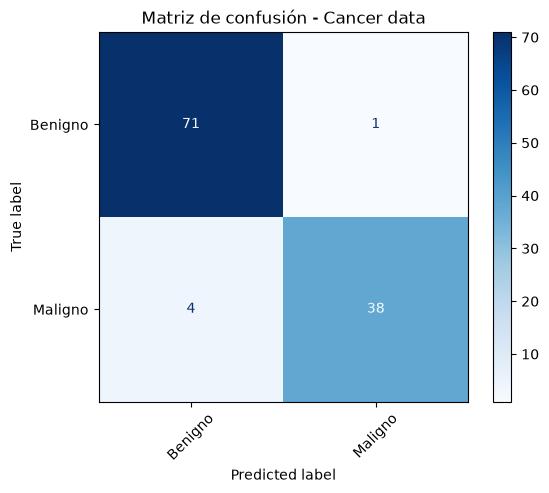

In [79]:
resultado_cancer = evaluar_knn_con_validacion(
    X=X_cancer,
    y=y_cancer,
    nombre_dataset='Cancer data',
    etiquetas=['Benigno', 'Maligno'],
    k_values=range(1, 21, 2),
)

**Lectura rápida:** si la matriz concentra la mayor parte de los casos en la diagonal, el modelo está separando bien ambas clases. En un problema médico, más allá del accuracy, conviene vigilar especialmente los falsos negativos.


## Challenge 2: Wine Quality data

**Objetivo:** predecir la calidad del vino a partir de sus propiedades físico-químicas.

Aquí sí usaremos el dataset de *Wine Quality* del reto. Como tenemos archivos de vino tinto y blanco, los uniremos en una sola base y conservaremos el tipo de vino como una característica adicional.


In [80]:
df_wine_red = pd.read_csv('data/winequality-red.csv', sep=';')
df_wine_red['wine_type'] = 'red'

df_wine_white = pd.read_csv('data/winequality-white.csv', sep=';')
df_wine_white['wine_type'] = 'white'

df_wine = pd.concat([df_wine_red, df_wine_white], ignore_index=True)

df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [81]:
df_wine['quality'].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

La calidad es nuestra etiqueta. Como `wine_type` es categórica, la convertimos a variables dummy antes de entrenar el modelo.


In [82]:
df_wine_model = pd.get_dummies(df_wine, columns=['wine_type'], drop_first=True)

X_wine = df_wine_model.drop(columns=['quality'])
y_wine = df_wine_model['quality']

X_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,False


=== Wine Quality data ===
K evaluadas: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
Validación cruzada usada: 4 folds
Mejor K: 27
Accuracy CV: 0.5565
Accuracy test: 0.5385

Reporte de clasificación:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        43
           5       0.60      0.58      0.59       428
           6       0.53      0.67      0.59       567
           7       0.44      0.32      0.37       216
           8       0.00      0.00      0.00        39
           9       0.00      0.00      0.00         1

    accuracy                           0.54      1300
   macro avg       0.22      0.23      0.22      1300
weighted avg       0.50      0.54      0.51      1300



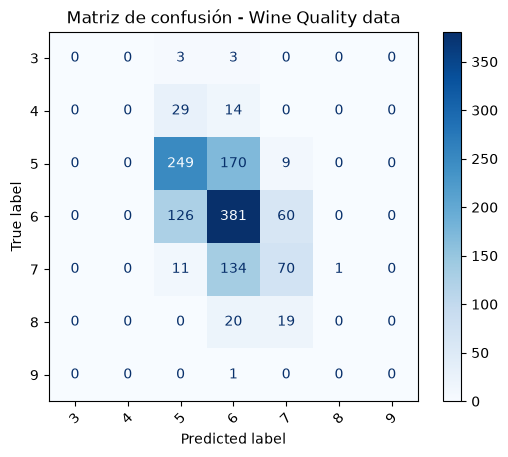

In [83]:
resultado_wine = evaluar_knn_con_validacion(
    X=X_wine,
    y=y_wine,
    nombre_dataset='Wine Quality data',
    etiquetas=[str(valor) for valor in sorted(y_wine.unique())],
    k_values=range(3, 31, 2),
)

**Lectura rápida:** este reto es más difícil porque hay varias clases de calidad y algunas están poco representadas. Por eso es normal que el desempeño sea más modesto que en el dataset de cáncer.


## Hallazgos clave y conclusión

### Hallazgos

**1. KNN funcionó mejor en el dataset de cáncer que en el de calidad del vino.**  
En el problema de cáncer, las clases están mejor definidas y separadas, por lo que el modelo logró clasificar con mayor precisión los casos benignos y malignos.

**2. El escalamiento de variables fue indispensable en ambos casos.**  
Como KNN depende de distancias entre observaciones, estandarizar o normalizar las variables fue un paso fundamental para evitar que unas columnas dominaran a otras por su escala.

**3. La selección de `K` influye directamente en el desempeño del modelo.**  
Probar varios valores mediante validación cruzada permitió elegir una mejor configuración que usar un valor arbitrario.

**4. El dataset de Wine Quality fue más difícil de modelar.**  
La calidad del vino tiene varias clases y algunas aparecen muy pocas veces, lo que dificultó la predicción y produjo métricas más bajas que en el caso del cáncer.

**5. Accuracy no siempre es suficiente para evaluar un modelo.**  
En ambos ejercicios fue importante revisar también la matriz de confusión y el reporte de clasificación para entender en qué clases el modelo se equivocaba más.

### Conclusión

El algoritmo K-Nearest Neighbors es una herramienta sencilla y útil para problemas de clasificación, pero su desempeño depende mucho de la estructura de los datos, de la escala de las variables y de la elección adecuada de `K`.

En este hands-on vimos que KNN puede funcionar muy bien cuando las clases están relativamente bien separadas, como en el dataset de cáncer. Sin embargo, también observamos que su rendimiento baja cuando el problema tiene más clases, desbalanceo o fronteras menos claras, como ocurrió en el dataset de calidad del vino.

En conjunto, ambos ejercicios muestran que aplicar un modelo no consiste solo en entrenarlo, sino también en preparar correctamente los datos, evaluar sus resultados e interpretar sus limitaciones.